In [76]:
import pandas as pd

df = pd.read_csv("telco.csv")

print("\nDataset shape : ")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDuplicated rows : ")
print(df.duplicated().sum())

print("\nDuplicated customer IDs : ")
print(df["customerID"].duplicated().sum())

print("\nInfo : ")
print(df.info())


Dataset shape : 
(7043, 22)

Columns:
Index(['Unnamed: 0', 'customerID', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')

Duplicated rows : 
0

Duplicated customer IDs : 
0

Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   customerID        7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure    

In [77]:
print("First 5 rows : ")
df.head()

First 5 rows : 


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


In [78]:
print(df["TotalCharges"].dtype)
df["TotalCharges"].head(10)

object


0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [79]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce" # Everywhere was " " put NaN
)

In [80]:
print(df["TotalCharges"].dtype)
print(df.isna().sum())

float64
Unnamed: 0           0
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [81]:
missing_total = df[df["TotalCharges"].isna()]

print(missing_total[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])

      customerID  tenure  MonthlyCharges  TotalCharges   Churn
488   4472-LVYGI       0           52.55           NaN  Stayed
753   3115-CZMZD       0           20.25           NaN  Stayed
936   5709-LVOEQ       0           80.85           NaN  Stayed
1082  4367-NUYAO       0           25.75           NaN  Stayed
1340  1371-DWPAZ       0           56.05           NaN  Stayed
3331  7644-OMVMY       0           19.85           NaN  Stayed
3826  3213-VVOLG       0           25.35           NaN  Stayed
4380  2520-SGTTA       0           20.00           NaN  Stayed
5218  2923-ARZLG       0           19.70           NaN  Stayed
6670  4075-WKNIU       0           73.35           NaN  Stayed
6754  2775-SEFEE       0           61.90           NaN  Stayed


In [82]:
df = df.dropna(subset=["TotalCharges"]) # Droping missing Values
print("Missing Values after droping them : ", df.isna().sum())

Missing Values after droping them :  Unnamed: 0          0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [83]:
df = df.drop(columns=["Unnamed: 0", "customerID"])

df.head

<bound method NDFrame.head of       gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female            No     Yes         No       1           No   
1       Male            No      No         No      34          Yes   
2       Male            No      No         No       2          Yes   
3       Male            No      No         No      45           No   
4     Female            No      No         No       2          Yes   
...      ...           ...     ...        ...     ...          ...   
7038    Male            No     Yes        Yes      24          Yes   
7039  Female            No     Yes        Yes      72          Yes   
7040  Female            No     Yes        Yes      11           No   
7041    Male           Yes     Yes         No       4          Yes   
7042    Male            No      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No      

In [84]:
X = df[["tenure", "MonthlyCharges", "Contract", "InternetService", "TechSupport", "PaymentMethod", "OnlineSecurity"]]
y = df["Churn"]

print("X Shape : ", X.shape)
print("y Shape : ", y.shape)

X Shape :  (7032, 7)
y Shape :  (7032,)


In [85]:
# One-Hot Encoding : 
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print(X.head())
print("Encoding X shape : ", X.shape)

   tenure  MonthlyCharges  Contract_One year  Contract_Two year  \
0       1           29.85                  0                  0   
1      34           56.95                  1                  0   
2       2           53.85                  0                  0   
3      45           42.30                  1                  0   
4       2           70.70                  0                  0   

   InternetService_Fiber optic  InternetService_No  InternetService_dsl  \
0                            0                   0                    0   
1                            0                   0                    0   
2                            0                   0                    0   
3                            0                   0                    0   
4                            1                   0                    0   

   TechSupport_No internet service  TechSupport_Yes  \
0                                0                0   
1                                0  

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 14)
X_test: (1407, 14)
y_train: (5625,)
y_test: (1407,)


In [87]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100, # 100 desision tree
    max_depth=5, # for Overfitting
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Model:", model)

Train: (5625, 14)
Test: (1407, 14)
Model: RandomForestClassifier(max_depth=5, random_state=42)


In [88]:
# Lets fit the model!

model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [89]:
y_pred = model.predict(X_test)
print("Prediction : ")
print(y_pred[:10])

print("Real Data : ")
print(y_test.head(10))

Prediction : 
['Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Churned' 'Churned'
 'Churned' 'Churned' 'Stayed']
Real Data : 
6294    Churned
5833     Stayed
5008     Stayed
629     Churned
6565     Stayed
3652    Churned
1381     Stayed
4901    Churned
2477     Stayed
480      Stayed
Name: Churn, dtype: object


In [90]:
from sklearn.metrics import accuracy_score

train_acc = model.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)

# Checking for Overfitting : 
print(f"Train Accuracy : {train_acc:.2%}")
print(f"Test Accuracy : {test_acc:.2%}") 

Train Accuracy : 79.68%
Test Accuracy : 80.10%


[[149 225]
 [ 55 978]]


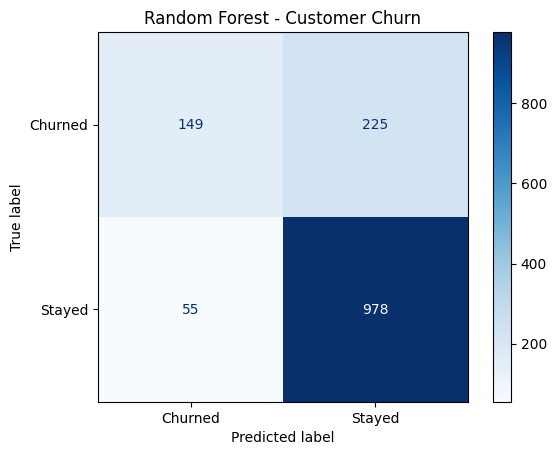

In [91]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Churned", "Stayed"]
)

print(cm)

cm_disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Churned", "Stayed"]
)

cm_disp.plot(cmap="Blues")

plt.title("Random Forest - Customer Churn")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("telco.csv")

print("\nDataset shape : ")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDuplicated rows : ")
print(df.duplicated().sum())

print("\nDuplicated customer IDs : ")
print(df["customerID"].duplicated().sum())

print("\nInfo : ")
print(df.info())


Dataset shape : 
(7043, 22)

Columns:
Index(['Unnamed: 0', 'customerID', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')

Duplicated rows : 
0

Duplicated customer IDs : 
0

Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   customerID        7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure    

In [ ]:
print("First 5 rows : ")
df.head()

First 5 rows : 


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,Stayed
1,1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,Stayed
2,2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Churned
3,3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,Stayed
4,4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Churned


In [ ]:
print(df["TotalCharges"].dtype)
df["TotalCharges"].head(10)

object


0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce" # Everywhere was " " put NaN
)

In [ ]:
print(df["TotalCharges"].dtype)
print(df.isna().sum())

float64
Unnamed: 0           0
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
missing_total = df[df["TotalCharges"].isna()]

print(missing_total[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])

      customerID  tenure  MonthlyCharges  TotalCharges   Churn
488   4472-LVYGI       0           52.55           NaN  Stayed
753   3115-CZMZD       0           20.25           NaN  Stayed
936   5709-LVOEQ       0           80.85           NaN  Stayed
1082  4367-NUYAO       0           25.75           NaN  Stayed
1340  1371-DWPAZ       0           56.05           NaN  Stayed
3331  7644-OMVMY       0           19.85           NaN  Stayed
3826  3213-VVOLG       0           25.35           NaN  Stayed
4380  2520-SGTTA       0           20.00           NaN  Stayed
5218  2923-ARZLG       0           19.70           NaN  Stayed
6670  4075-WKNIU       0           73.35           NaN  Stayed
6754  2775-SEFEE       0           61.90           NaN  Stayed


In [ ]:
df = df.dropna(subset=["TotalCharges"]) # Droping missing Values
print("Missing Values after droping them : ", df.isna().sum())

Missing Values after droping them :  Unnamed: 0          0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df = df.drop(columns=["Unnamed: 0", "customerID"])

df.head

<bound method NDFrame.head of       gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female            No     Yes         No       1           No   
1       Male            No      No         No      34          Yes   
2       Male            No      No         No       2          Yes   
3       Male            No      No         No      45           No   
4     Female            No      No         No       2          Yes   
...      ...           ...     ...        ...     ...          ...   
7038    Male            No     Yes        Yes      24          Yes   
7039  Female            No     Yes        Yes      72          Yes   
7040  Female            No     Yes        Yes      11           No   
7041    Male           Yes     Yes         No       4          Yes   
7042    Male            No      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No      

In [ ]:
X = df[["tenure", "MonthlyCharges", "Contract", "InternetService", "TechSupport", "PaymentMethod", "OnlineSecurity"]]
y = df["Churn"]

print("X Shape : ", X.shape)
print("y Shape : ", y.shape)

X Shape :  (7032, 7)
y Shape :  (7032,)


In [ ]:
# One-Hot Encoding : 
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print(X.head())
print("Encoding X shape : ", X.shape)

   tenure  MonthlyCharges  Contract_One year  Contract_Two year  \
0       1           29.85                  0                  0   
1      34           56.95                  1                  0   
2       2           53.85                  0                  0   
3      45           42.30                  1                  0   
4       2           70.70                  0                  0   

   InternetService_Fiber optic  InternetService_No  InternetService_dsl  \
0                            0                   0                    0   
1                            0                   0                    0   
2                            0                   0                    0   
3                            0                   0                    0   
4                            1                   0                    0   

   TechSupport_No internet service  TechSupport_Yes  \
0                                0                0   
1                                0  

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 14)
X_test: (1407, 14)
y_train: (5625,)
y_test: (1407,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100, # 100 desision tree
    max_depth=5, # for Overfitting
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Model:", model)

Train: (5625, 14)
Test: (1407, 14)
Model: RandomForestClassifier(max_depth=5, random_state=42)


In [ ]:
# Lets fit the model!

model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [ ]:
y_pred = model.predict(X_test)
print("Prediction : ")
print(y_pred[:10])

print("Real Data : ")
print(y_test.head(10))

Prediction : 
['Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Churned' 'Churned'
 'Churned' 'Churned' 'Stayed']
Real Data : 
6294    Churned
5833     Stayed
5008     Stayed
629     Churned
6565     Stayed
3652    Churned
1381     Stayed
4901    Churned
2477     Stayed
480      Stayed
Name: Churn, dtype: object


In [ ]:
from sklearn.metrics import accuracy_score

train_acc = model.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)

# Checking for Overfitting : 
print(f"Train Accuracy : {train_acc:.2%}")
print(f"Test Accuracy : {test_acc:.2%}") 

Train Accuracy : 79.68%
Test Accuracy : 80.10%


[[149 225]
 [ 55 978]]


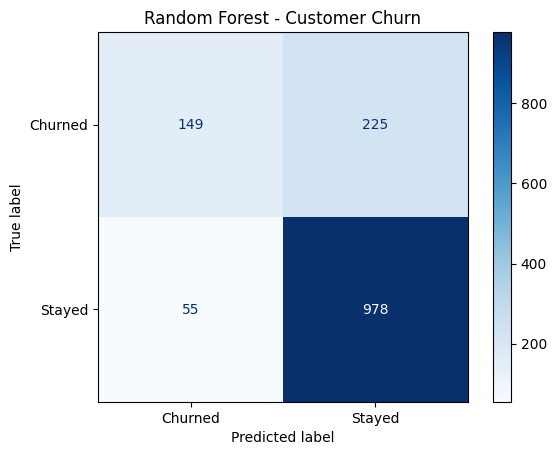

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Churned", "Stayed"]
)

print(cm)

cm_disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Churned", "Stayed"]
)

cm_disp.plot(cmap="Blues")

plt.title("Random Forest - Customer Churn")
plt.show()